In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split,cross_val_score,GridSearchCV
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import Ridge #
import warnings
from sklearn.pipeline import Pipeline

In [ ]:
#Load data (California housingni yuklash)
data = fetch_california_housing(as_frame=True)
df = data.frame
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
#Prepare data (X va y ajratish, split qilish)
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [83]:
baseline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

cv_scores = cross_val_score(baseline, X_train, y_train, cv=5, scoring="r2")
print("Baseline CV R2:", cv_scores)
print("Baseline CV R2 mean:", cv_scores.mean())

Baseline CV R2: [0.62011512 0.61298876 0.6134416  0.61069973 0.60017477]
Baseline CV R2 mean: 0.6114839952560993


In [84]:
baseline.fit(X_train, y_train)
y_pred_base = baseline.predict(X_test)

print("Baseline Test R2:", r2_score(y_test, y_pred_base))
print("Baseline Test MAE:", mean_absolute_error(y_test, y_pred_base))
print("Baseline Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_base)))


Baseline Test R2: 0.5757877060324508
Baseline Test MAE: 0.5332001304956566
Baseline Test RMSE: 0.7455813830127764


In [85]:
# 2️ Hyperparameter grid
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

In [86]:
ridge_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge())
])

param_grid = {
    "model__alpha": [0.01, 0.1, 1, 10, 100]
}

grid = GridSearchCV(
    ridge_pipe,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
print("Best CV R2:", grid.best_score_)

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best Params: {'model__alpha': 0.01}
Best CV R2: 0.6114839924016692


In [87]:
best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test)

before_r2 = r2_score(y_test, y_pred_base)
after_r2  = r2_score(y_test, y_pred_best)

before_mae = mean_absolute_error(y_test, y_pred_base)
after_mae  = mean_absolute_error(y_test, y_pred_best)

before_rmse = np.sqrt(mean_squared_error(y_test, y_pred_base))
after_rmse  = np.sqrt(mean_squared_error(y_test, y_pred_best))

print("\n=== BEFORE (LinearRegression) ===")
print("R2:", before_r2, " MAE:", before_mae, " RMSE:", before_rmse)

print("\n=== AFTER (Ridge tuned) ===")
print("R2:", after_r2, " MAE:", after_mae, " RMSE:", after_rmse)


=== BEFORE (LinearRegression) ===
R2: 0.5757877060324508  MAE: 0.5332001304956566  RMSE: 0.7455813830127764

=== AFTER (Ridge tuned) ===
R2: 0.5757879873121597  MAE: 0.5332000589081537  RMSE: 0.7455811358288167


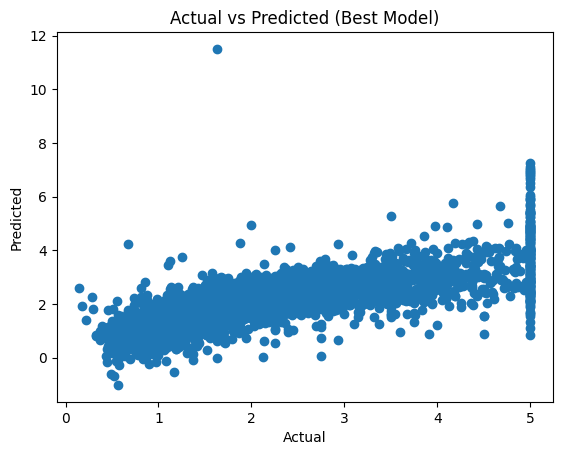

In [88]:
plt.scatter(y_test, y_pred_best)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted (Best Model)")
plt.show()

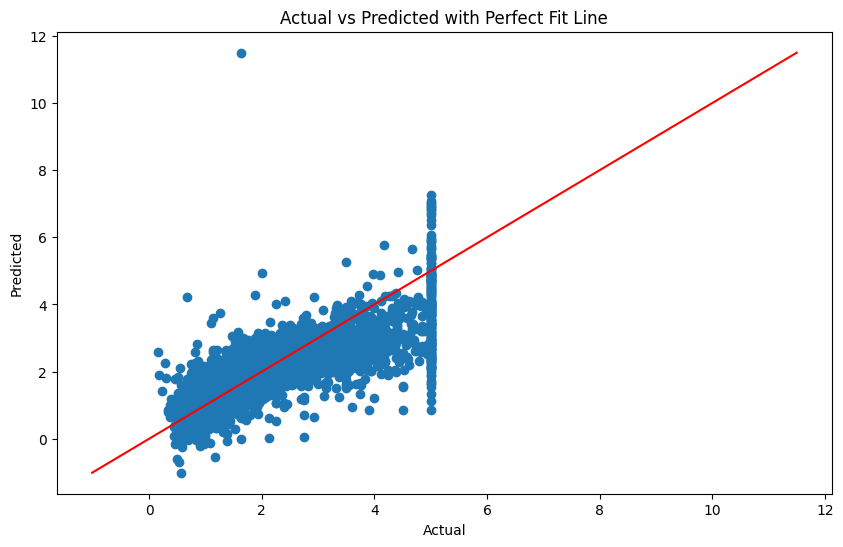

In [95]:
plt.figure(figsize=(10,6))

plt.scatter(y_test, y_pred_best)

# diagonal line (perfect prediction line)
min_val = min(y_test.min(), y_pred_best.min())
max_val = max(y_test.max(), y_pred_best.max())

plt.plot([min_val, max_val], [min_val, max_val], color='red')

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted with Perfect Fit Line")
plt.show()

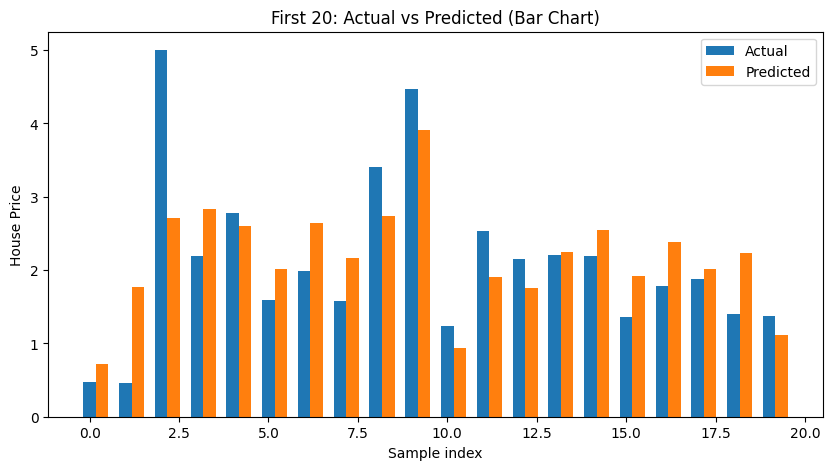

In [ ]:

n = 20
index = np.arange(n)
width = 0.35
plt.figure(figsize=(10,5))

plt.bar(index, y_test.values[:n], width, label="Actual")
plt.bar(index + width, y_pred_best[:n], width, label="Predicted")

plt.xlabel("Sample index")
plt.ylabel("House Price")
plt.title("First 20: Actual vs Predicted (Bar Chart)")
plt.legend()
plt.show()

In [90]:
compare20 = pd.DataFrame({
    "Actual": y_test.values[:20],
    "Predicted": y_pred_best[:20]
})
compare20["Error"] = compare20["Actual"] - compare20["Predicted"]
compare20


,Actual,Predicted,Error
0,0.47700,0.719126,-0.242126
1,0.45800,1.764015,-1.306015
2,5.00001,2.709655,2.290355
3,2.18600,2.838924,-0.652924
4,2.78000,2.604652,0.175348
5,1.58700,2.011755,-0.424755
6,1.98200,2.645500,-0.663500
7,1.57500,2.168755,-0.593755
8,3.40000,2.740740,0.659260
9,4.46600,3.915616,0.550384


In [91]:
#greatsearchCV Automoatik hyperparametr search

In [92]:
#compare  before and after

In [93]:
# vizualization